# 01 — ADJSCC Stage Walkthrough

Push one CIFAR image through every stage of the pipeline and **see** what each does.
Paper: [Wireless Image Transmission Using Deep Source Channel Coding With Attention Modules](https://arxiv.org/abs/2012.00533).

Pipeline: **image → encoder (CNN+AF) → power norm → AWGN channel → decoder → image**.

Needs a trained checkpoint (see `../docs/PLANO.md`). Train quick one first:
```
python train.py --cond af --ratio 0.1667 --epochs 30 --out ckpt/adjscc_r16.pt
```

In [5]:
import sys, torch, numpy as np, matplotlib.pyplot as plt
sys.path.append('..')
from adjscc.models import DeepJSCC
from adjscc.data import loaders
from adjscc.metrics import psnr
from adjscc.engine import pick_device
dev = pick_device(); dev

'mps'

In [6]:
ck = torch.load('../ckpt/adjscc_r16.pt', map_location=dev)
m = DeepJSCC(C=ck['C'], F=ck['args']['filters'], cond='af').to(dev)
m.load_state_dict(ck['state_dict']); m.eval()
print('C=', ck['C'], ' R=', ck['C']/96, ' trained PSNR', round(ck['psnr'],2))

C= 16  R= 0.16666666666666666  trained PSNR 33.13


100.0%


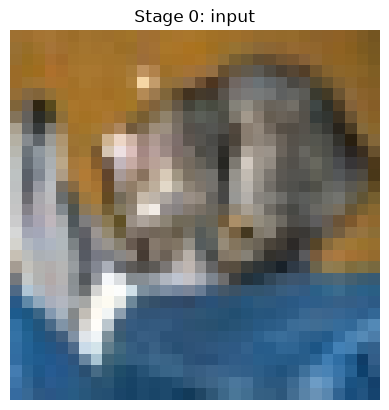

In [7]:
_, test = loaders(batch=8)
img, _ = next(iter(test)); img = img.to(dev)
x = img[:1]  # one image
plt.imshow(x[0].cpu().permute(1,2,0)); plt.title('Stage 0: input'); plt.axis('off');

## Stage 1 — Encoder feature maps
CNN compresses the image into `C` channels at 8×8. These become the transmitted symbols.

feature map (1, 16, 8, 8)


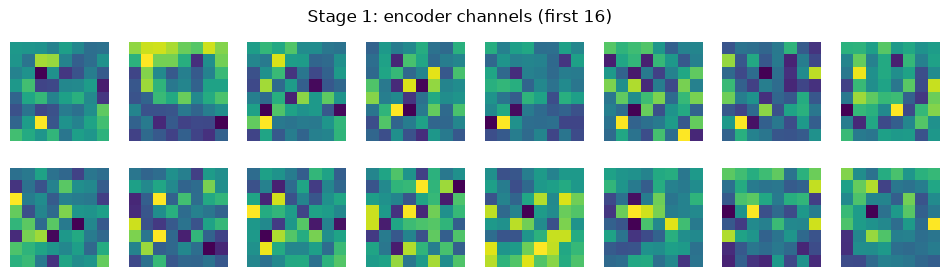

In [8]:
snr = 10.0
with torch.no_grad():
    snr_vec = m._snr_vec(snr, 1, dev)
    feat = m.enc(x, snr_vec)  # (1,C,8,8)
print('feature map', tuple(feat.shape))
fig, ax = plt.subplots(2,8, figsize=(12,3))
for i,a in enumerate(ax.flat):
    a.imshow(feat[0, i%feat.shape[1]].cpu()); a.axis('off')
fig.suptitle('Stage 1: encoder channels (first 16)');

## Stage 2+3 — Power-normalized symbols → AWGN channel
Pair reals into complex symbols and scatter them (constellation). Watch noise spread as SNR drops.

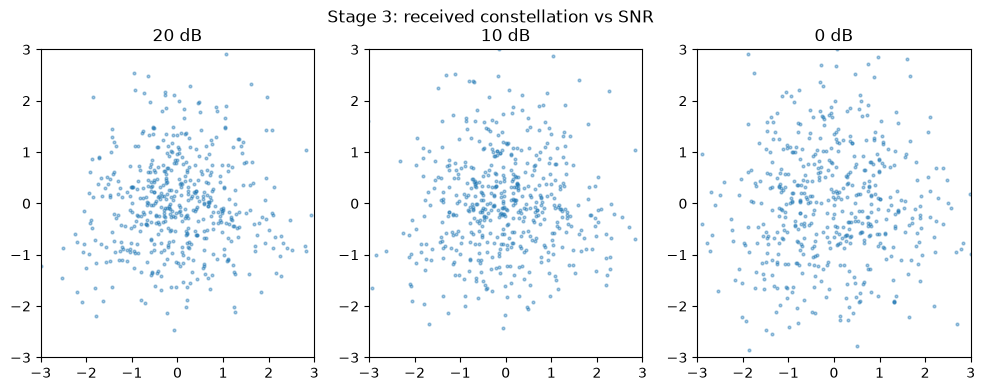

In [9]:
from adjscc.channel import power_normalize, awgn
with torch.no_grad():
    z = power_normalize(feat.flatten(1))  # (1, C*64)
    half = z.shape[1]//2
    tx = z[0].cpu().numpy(); txc = tx[:half] + 1j*tx[half:]
fig, ax = plt.subplots(1,3, figsize=(12,4))
for a, s in zip(ax, [20,10,0]):
    with torch.no_grad():
        y = awgn(z, float(s))[0].cpu().numpy()
    yc = y[:half] + 1j*y[half:]
    a.scatter(yc.real, yc.imag, s=4, alpha=.4)
    a.set_title(f'{s} dB'); a.set_xlim(-3,3); a.set_ylim(-3,3)
fig.suptitle('Stage 3: received constellation vs SNR');

## Stage 4 — Decoder reconstruction across SNR
Same single model, swept over SNR. AF modules adapt it to each channel condition.

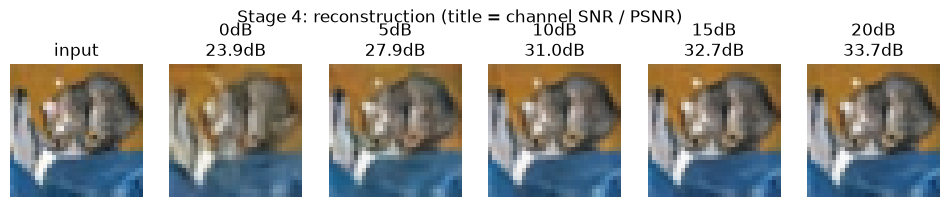

In [10]:
snrs = [0,5,10,15,20]
fig, ax = plt.subplots(1, len(snrs)+1, figsize=(2*(len(snrs)+1),2.5))
ax[0].imshow(x[0].cpu().permute(1,2,0)); ax[0].set_title('input'); ax[0].axis('off')
for a, s in zip(ax[1:], snrs):
    with torch.no_grad(): out = m(x, float(s))
    a.imshow(out[0].cpu().permute(1,2,0).clamp(0,1))
    a.set_title(f'{s}dB\n{psnr(out,x):.1f}dB'); a.axis('off')
fig.suptitle('Stage 4: reconstruction (title = channel SNR / PSNR)');